# Social Finance

**Jonathan Conning**,
Department of Economics, 
Hunter College and The Graduate Center, 
City University of New York

**Jonathan Morduch**, 
NYU Wagner Graduate School of Public Service

**Abstract:**  We propose a framework for understanding how social investors’ who seek to maximize a combination of private and social returns from investments in a portfolio of new and established microfinance institutions.  The model takes into account the endogeneity of loan contract terms as well as the capital structure of the financial institutions that may emerge to serve target groups of borrowers differentiated primarily by their levels of initial average net worth, and how social investments might transform those patterns. We build upon one of the workhorse models of modern corporate finance (Tirole, 2007) which features limited liability, multiple layers of moral hazard and costly monitoring to explain patterns of financial intermediation, and in our framework, the role and modes of social investment.  We pinpoint the role of the subsidies and guarantees implicit in social investors’ equity and quasi-equity investments and the role they play in attracting private capital investors and sustaining productivity-enhancing financial intermediation that might otherwise not have taken place. 

**Note: **This is written as a jupyter Notebook to serve as an online appendix and scratchpad for the paper. With no pretension to being complete it contains a summary of some of the main arguments, derivations and and python code for simulations/visualizations. In due time it may evolve into a more complete and polished.

## Introduction

...We tackle the logic and tensions inherent in social finance—the support, with philanthropic objectives, of nonprofits, social businesses like the Grameen Bank, and profit-maximizing businesses serving the poor. The principles behind the new world of philanthropy and social action have not been well-explored by economists. We develop a theory of “social finance” to parallel the modern theory of corporate finance... 


## The Model

We extend a model of capital constraints and financial intermediation with active monitors similar to Holmstrom and Tirole (1997), Conning (1999), but extends the model to focus on how bank capital structure varies across banks depending on the monitoring-intensity of their loan portfolio (determined in turn by the average net worth of its borrowers) and the role that social investors may play in creating and expanding loan access via structured finance. 

This model itself is built upon a simple model of credit rationing due to borrower moral hazard and limited liability, the 'workhorse' model of Tirole's (2006) *The Theory of Corporate Finance*.  Risk-neutral entrepreneurs have access to an investment project which requires a lump-sum investment $I$ to get started, but they do not have liquid funds so they seek to borrow the entire amount from financial intermediaries. The problem of moral hazard will dictate that optimal contracts must reward project success more highly than project failure in order to give entrepreneurs an incentive to want to increase the probability of success.  Under many plausible parameter scenaries te optimal contract will require that loan repayments in the failure state(s) be met out of assets that are additional or 'collateral' to the generated project returns.  Lenders will find it unprofitable to lend to any borrower who cannot credibly pledge assets below a minimum collateral requirement $\underline A$.  A simple graphical analysis of this collateral based lending model is laid out in a notebook [here](basicmodel.ipynb)

Local intermediaries may be able in 'active monitoring' that directly lowers borrowers' scope for moral hazard, lowering the minimum collateral requirements necessary to attract outside investors, thereby expanding capital access.  But monitoring is a costly activity that is itself subject to moral hazard. For this reason an optimal contract will require monitoring intermediaries to have enough of their own capital at risk in a loan so as to provide incentives to appropriately monitor to protect any outside investor's interests. 

In contrast to the earlier mentioned papers, in this paper we posit the idea that local intermediary monitoring capacity is neighborhood-specific, and neighborhoods are largely segregated by the average level of pledgeable assets of its residents.  This leads us to a focus on the optimal capital structure of neighborhood-specific banks (or more broadly to the optimal capital structure of different types of banks, depending on the monitoring intensity of their loan portfolio). 

There are up to four types of agents in the model:

1. risk-neutral entrepreneur households that can run small businesses if they are able to cover lump sum $I$. Household differ in terms of their initial pledgeable assets $A$ (tied up in other projects but can be liquidated at a cost to cover obligations. 
2. one or more local financial intermediaries in each neighborhood, wholly or partly owned and managed by locally informed equity investors. These financial institutions may lend out of their own equity capital. Their own at risk investment in a particular entreprenneur's project is labeled $I^m$ to indicate that they monitor to try to limit scope for moral hazard.
3. private uninformed investors (possibly including savings depositors). 
4. Finally, social investors may be able to affect the nature and depth of the above relationsips through additional investments, subsidies and guarantees of their own. 

Entrepreneurs in neighborhood $j$ have pledgeable assets $A_j$ (assets that are tied up in other productive uses but could be liquidated to pay off a loan).  Depending on the characteristics of the loan projects and the level of $A_j$ the model generates one of four types of lending structures: 

Depending on their initial holding of $A$ and parameters of the problem, entrepreneurs will in the end be either:
1. not funded
2. funded only by a non-leveraged local intermediary, so $I = I^m$
3. funded by a leveraged intermediary: so $I = I^m + I^u$

The model can be closed so that, depending on the characteristics of loans, the initial distribution of pledgeable assets across neighborhoods and entrepreneurs,  and the economy-wide levels of intermediary and uninformed capital we can predict the rate of return on uninformed and intermediary capital as well as bank capital structure and loan terms across the population.



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
%matplotlib inline

### Parameters

In [19]:
X = 200       #Project returns under success (=0 under failure)
p = 0.97      #probability of success if diligent
q = 0.82      #probability of success if non-diligent
I = 100
gamma = 1     # outside lenders' cost of funds

** Intermediary fixed cost per borrower **
We start off by ignoring.by setting to zero

In [20]:
F = 0        # Fixed cost just to operate
f = 0
def FC(N):   #Avg fixed cost per borrower if bank has N borrowers
    return F/N + f

**Monitoring technology:** For simplicity and to fix ideas we assume a linear relationship betweeen more monitoring expense and the extent of moral hazard (the private benefits the client stands to capture from non-diligence)

In [21]:
B0 = 30
alpha = 0.4
def B(m): 
    '''Private benefit to non-diligence if mon intensity m'''
    return B0 - alpha*4

In [22]:
def B(m, B0=30, alpha=0.4):
    '''Private benefits as a function of monitoring m'''
    return B0 - alpha*m

### Distribution of entrepreneurs and assets across neighborhoods
There are $J$ neighborhoods with $N$ enterepreneurs per neighborhood.

Pledgeable asset per household ranges from 0 to $A^{max}$.  

Neighborhoods are segregated by income. In poorest neighborhood household has $A=0$
in richest neighborhood typical household has $A=A^{max}$

In [23]:
Amax = 120         # highest pledgeable asset value
J = Amax            # number of neighborhoods
N = 1000           # entrepreneurs per neighborhood
pop = J*N          # total population
Kneed = J * N * I  # demand for finance if all funded.
mu = 1/2           # available intermediary capital as share of Kneed   
Ktot = mu*Kneed    # available intermediary capital  

In [24]:
print('There are {} neighborhoods with {} entrepreneurs each'.format(J,N))
print('Total loan demand is {:5.0f} thousand'.format(Kneed/1000))
print('but local intermediary capital can directly fund only {:5.0f} thousand'.format(Ktot/1000))

There are 120 neighborhoods with 1000 entrepreneurs each
Total loan demand is 12000 thousand
but local intermediary capital can directly fund only  6000 thousand


Let's work first with a simple uniform distribution across neighborhoods. In effect all $N$ entrepreneurs in neighborhood $j$ have $A=j$ in assets and there are $J=A^{max}$ neighborhoods.  Initially $N=1000$ and $A^{max}=120$

In [25]:
Nj = np.ones(J+1)*N     # assets and population uniform across neighborhoods
A = np.linspace(0, Amax, J+1) # all in neighborhood j have A=(Amax/J)*j

### Minimum collateral requirements

As explained also in [basic model](basicmodel.ipynb) we can calculate a minimum collateral requirement for non-monitored loans.  We extend the logic here to include the possibility of monitored loans. 

A contract divides project claims between returns $s_i$ to the entrepreneur, returns $R_i^m$ to the intermediary monitor (if monitoring is worthwhile) and returns $R_i^u = x_i - s_i - R_i^m$ to the uninformed bank.  

An uninformed bank will be willing to participate if the contract provides incentives for the borrower to be diligent in the production project (i.e. choose $p$ rather than $q$) and if a monitor is involved that the monitor also have incentives to monitor at the minimum monitoring intensity required, and expected repayments are sufficient to cover the opportunity cost of funds.

The **entrepreneur's incentive constraint**:
$$E[s|p] \ge E[s|q] + B$$
or
$$s_s \ge s_f + \frac{B}{p-q} $$

The **monitor's incentive constraint** states they must gain more from costly monitoring $m$ than without:

$$E[R^m|p] \ge E[R^m|q] + m$$
or
$$R_s^m \ge R_f^m + \frac{m}{p-q} $$

**Bank participation constraint:** Expected repayments to the uninformed bank must be enough for it to break even:

$$E[X|p] - E[s|p] - E[m|p] = \gamma I$$

**Minimum Collateral Requirement with zero monitoring $\bar A(0)$:**

Monitoring is a costly mechanism to reduce minimum collateral requirements. So it will only be used when there is no other choice.   Let's first figure out the minimum collateral requirement with zero monitoring.

Since the project generates zero returns under failure, the borrower's repayment will be entirely out of collateral, and their payoff in that state will be:
$$s_f = - \bar A$$

To meet the incentive constraint at minimum cost we need to set the success return to the borrower sufficiently high:
$$s_s = - \bar A + \frac{B(0)}{p-q}$$
This combination of terms implies that the minimum required expected payment to a borrower who can post $\bar A$ must be at least:

$$E[s|p] = - \bar A + p \cdot \frac{B(0)}{p-q}$$
Placing this into the bank's binding participation constraint and re-arranging we can solve for the minimum collateral requirement that just allows the bank to break even on the loan:

$$ \bar A(0)= p \cdot \frac{B(0)}{p-q} - [E[X|p]-\gamma I]$$

The bank cannot profitably lend to a borrower with pledgeable assets $A$ less than $\bar A$. 

**Minimum Collateral Requirement with monitoring:**

How to reach borrowers who have less than 

**Entrepreneur's Limited Liability**:

$$s_f \ge -A$$

**Non-leverage or equity-only MFI**

$$\underline A^e(m,N) = \frac{p B(m)}{p-q} - \left[ {pX - \gamma I} \right] + F/N + m$$


When the MFI can leverage outside capital it can now substitute cheaper outside financing for equity capital (remember $\beta > \gamma$ so long as monitoring intermediary capital is relatively scarce. On the other hand monitoring costs rise fast because we have to provide incentives to both the borrower and the monitor. 

**Leveraged MFI**

$$\underline A (m,N) = \frac{p(B(m)}{p-q} - \left[ {pX - \gamma I} \right] 
+ \frac{\beta - \gamma}{\beta} \left( \frac{q \cdot m}{p-q} \right ) + F/N + m$$

In [9]:
def AMe(m, beta, n=N):
    '''Minimum collateral for non-leveraged or equity-only MFI '''
    return p/(p-q)*B(m) - p*X + beta*I + m + FC(n)

def AM(m, beta, n = N):
    '''Minimum collateral for leveraged MFI '''
    fundingcost =  gamma*I  + ((beta-gamma)/beta)*(q*m/(p-q))
    return p/(p-q)*B(m) - p*X + m +fundingcost +FC(n)

In [10]:
mm = np.linspace(0,Amax)
AMe(mm,1)

array([100.        ,  96.11428571,  92.22857143,  88.34285714,
        84.45714286,  80.57142857,  76.68571429,  72.8       ,
        68.91428571,  65.02857143,  61.14285714,  57.25714286,
        53.37142857,  49.48571429,  45.6       ,  41.71428571,
        37.82857143,  33.94285714,  30.05714286,  26.17142857,
        22.28571429,  18.4       ,  14.51428571,  10.62857143,
         6.74285714,   2.85714286,  -1.02857143,  -4.91428571,
        -8.8       , -12.68571429, -16.57142857, -20.45714286,
       -24.34285714, -28.22857143, -32.11428571, -36.        ,
       -39.88571429, -43.77142857, -47.65714286, -51.54285714,
       -55.42857143, -59.31428571, -63.2       , -67.08571429,
       -70.97142857, -74.85714286, -78.74285714, -82.62857143,
       -86.51428571, -90.4       ])

At zero monitoring it's obviously cheaper to use uninformed capital which has lower cost $\gamma$ rather than borrow from an local intermediary capital which has opportunity cost $\beta$.  Since the latter type of loans are more expensive, they'll also be associated with higher minimum collateral requirements.  Suppose $\beta = 1.2 \cdot \gamma$, then:

In [11]:
AMe(0,gamma*1.2), AM(0,gamma*1.2)

(119.99999999999997, 99.99999999999997)

In general borrowers will look for the cheapest loans they can obtain given their pledgeable assets $A$.  

In [12]:
mm = np.linspace(0,Amax)
def plotA(beta):
    plt.plot(mm, AMe(mm, beta), label='equity only MFI')
    plt.plot(mm,AM(mm,beta), label='leveraged MFI')
    plt.xlim(0,Amax), plt.ylim(0,Amax)
    plt.title('Minimum Collateral requirement')
    plt.xlabel('monitoring intensity $m$')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

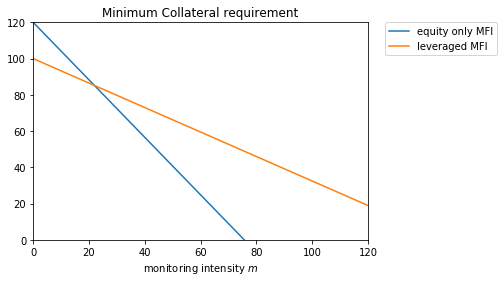

In [13]:
plotA(1.2)

**Monitoring intensity, intermediary capital and borrower participation** as a function of pledgeable assets A:

In [14]:
def mon(A, beta, N):
    '''optimal monitoring intensity in leveraged MFI'''
    Ahi = p*X - beta*I     #min collateral for no-monitoring loan
    return (Ahi - A)*((beta*(p-q))/(alpha-1)*beta*p+gamma*q)

def monE(A, beta, N):
    '''optimal monitoring intensity in leveraged MFI'''
    Ahi = p*X - beta*I     #min collateral for no-monitoring loan
    return ((A - Ahi) - (beta - gamma*I))*((p-q)/((1-alpha)*p-q))

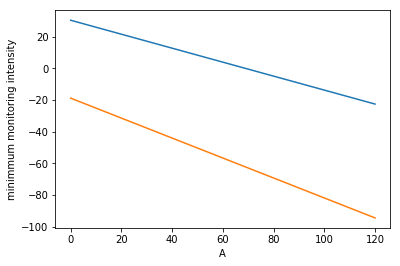

In [15]:
plt.plot(mon(A,1.25, N))
plt.plot(monE(A,1.25, N))
plt.xlabel('A')
plt.ylabel('minimmum monitoring intensity');

In general, the supply of players with _both_ the expertise to monitor the entrepreneur and their own capital to invest in the firm is limited. (Tirole p361) 

**Plot helper functions**.  As we'll be plotting a lot of linear (and non-linear) functions it will be useful to create a simple 'function factory' foto setup lines to be plotted and a plotter function that takes a variable number of line functions to be plotted.

In [16]:
def line_function(a, b):
    '''function factory to return a line function 
    of the form f(x) = a + b*x'''
    def f(x):
        return a + b*x
    return f

def plotter(*args, mmax = 80, title=''): 
    '''plot contract constraints
    Accepts a variable number of lines/constraint functions to plot
    on the same diagram'''
    m = np.linspace(0, mmax, mmax+1)  # plot range
    for count, fn in enumerate(args):              
        plt.plot(m, fn(m))
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    plt.title(title)
    plt.ylim(0, Amax)  

In [17]:
plotter(foo, title='Min. Collateral and monitoring intensity')

NameError: name 'foo' is not defined